# Team ZeroTrustAI — one aggregator for both tracks

**Project:** *Flag, Drop, Clip — and stop weighting by size.* This is the organisers' Day 2 notebook with the
`🔧 YOUR TURN` hooks filled in. Everything our Writeup claims is computed below; nothing is hard-coded.

What we changed, and only this:
1. **One line in `run_fl`** (Section 4): it reseeds at the start of every run, so "before" and "after" share the same
   initial weights and batch order, and so we can repeat every comparison over 5 seeds.
2. **One aggregation function, `make_agg`**, used for *both* tracks through the `agg_fn` hook.

The model (`WeakMLP`, 8 hidden units), local training, rounds, data split and attack code are untouched.

# CAIRLab Hackathon — Day 2 Extension: Intermediate + Advanced Tracks

Two new tracks unlock today, and you're free to attempt either or both between now and the
submission deadline:

| Track | Goal |
|---|---|
| 🟡 Intermediate | Client data is realistically **skewed** across the five banks — naive FedAvg performs worse under this skew. Fix the **aggregation**. |
| 🔴 Advanced (optional) | Partway through, one bank turns malicious and sends sabotaged updates. **Detect or resist** the attack. |

This notebook is self-contained — it rebuilds the dataset, partitions, model, and FL harness
from scratch, so you don't need yesterday's notebook open. The ideas carry over directly:
same story, same weak baseline, same FedAvg loop as Day 1, extended with what you need for
today's tracks.

**Scoring today:** unlike Day 1, these tracks aren't on a Kaggle leaderboard — a static
prediction file can't capture "how your aggregation holds up under skew" or "how much F1 your
defense recovers under attack." Instead, you'll report your before/after comparison in your
Kaggle Writeup, and export your final model for the organizers to spot-check. See the
Evaluation Rubric on the hackathon page for exact scoring weights.


## 0. Setup

In [1]:

# (pip --upgrade removed: using the preinstalled versions keeps the numbers reproducible)
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import copy, json, os, hashlib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs("data", exist_ok=True)
print("Setup complete.")


Setup complete.


## 1. Load and clean the dataset (same as Day 1)


In [2]:

TRAIN_URL = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt"
TEST_URL  = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt"

COLS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty",
]

# use the repo's local copy if present (identical files), else download
if os.path.exists("data/KDDTrain+.txt"): TRAIN_URL, TEST_URL = "data/KDDTrain+.txt", "data/KDDTest+.txt"
train_raw = pd.read_csv(TRAIN_URL, names=COLS)
test_raw  = pd.read_csv(TEST_URL, names=COLS)

def clean(df):
    df = df.drop(columns=["difficulty"]).copy()
    df["binary_label"] = (df["label"] != "normal").astype(int)
    return df

train_df = clean(train_raw)
test_df  = clean(test_raw)

CAT_COLS = ["protocol_type", "service", "flag"]
encoders = {}
for c in CAT_COLS:
    le = LabelEncoder()
    le.fit(pd.concat([train_df[c], test_df[c]], axis=0))
    train_df[c] = le.transform(train_df[c])
    test_df[c]  = le.transform(test_df[c])
    encoders[c] = le

FEATURE_COLS = [c for c in train_df.columns if c not in ["label", "binary_label"]]

scaler = StandardScaler()
train_df[FEATURE_COLS] = scaler.fit_transform(train_df[FEATURE_COLS])
test_df[FEATURE_COLS]  = scaler.transform(test_df[FEATURE_COLS])

print("features:", len(FEATURE_COLS))


features: 41


## 2. Partition into 5 clients — IID (for reference) and non-IID (today's data)

Same holdout reservation logic as Day 1 (same seed, so it's the identical reserved rows —
this doesn't matter for today's scoring, it's just kept consistent).

Today you also get a **non-IID** partition: the same pool of training rows, but split so
each "bank" sees a skewed slice of traffic — one might see mostly denial-of-service attacks,
another almost entirely normal traffic. This is realistic (different banks see different
customers and attackers), and it's what breaks naive FedAvg.


In [3]:

N_CLIENTS = 5
HOLDOUT_SIZE = 15000

_rng = np.random.RandomState(SEED)
_perm = _rng.permutation(len(train_df))
_holdout_idx = _perm[:HOLDOUT_SIZE]
_pool_idx = _perm[HOLDOUT_SIZE:]
train_pool = train_df.iloc[_pool_idx].reset_index(drop=True)

def make_iid_partition(df, n_clients=N_CLIENTS, seed=SEED):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(df))
    chunks = np.array_split(idx, n_clients)
    return [df.iloc[c].reset_index(drop=True) for c in chunks]

FAMILY_MAP = {
    "normal": "normal",
    "neptune": "dos", "back": "dos", "land": "dos", "pod": "dos", "smurf": "dos",
    "teardrop": "dos", "apache2": "dos", "udpstorm": "dos", "processtable": "dos",
    "worm": "dos", "mailbomb": "dos",
    "satan": "probe", "ipsweep": "probe", "nmap": "probe", "portsweep": "probe",
    "mscan": "probe", "saint": "probe",
}

def make_noniid_partition(df, n_clients=N_CLIENTS, alpha=0.3, seed=SEED):
    '''Dirichlet-skewed split by attack family. Low alpha = strong skew.'''
    rng = np.random.RandomState(seed)
    df = df.copy()
    df["family"] = df["label"].map(lambda x: FAMILY_MAP.get(x, "r2l_u2r_other"))
    client_indices = [[] for _ in range(n_clients)]
    for fam in df["family"].unique():
        fam_idx = df.index[df["family"] == fam].to_numpy().copy()
        rng.shuffle(fam_idx)
        proportions = rng.dirichlet(alpha=[alpha] * n_clients)
        split_points = (np.cumsum(proportions) * len(fam_idx)).astype(int)[:-1]
        for i, s in enumerate(np.split(fam_idx, split_points)):
            client_indices[i].extend(s.tolist())
    out = []
    for ci in client_indices:
        rng.shuffle(ci)
        out.append(df.loc[ci].drop(columns=["family"]).reset_index(drop=True))
    return out

iid_clients = make_iid_partition(train_pool)
noniid_clients = make_noniid_partition(train_pool)

print("IID sizes:", [len(c) for c in iid_clients])
print("\\nNon-IID sizes:", [len(c) for c in noniid_clients])
for i, c in enumerate(noniid_clients):
    print(f"  client {i} label mix:", c["binary_label"].value_counts(normalize=True).round(2).to_dict())


IID sizes: [22195, 22195, 22195, 22194, 22194]
\nNon-IID sizes: [6272, 10658, 48219, 23239, 22585]
  client 0 label mix: {1: 0.81, 0: 0.19}
  client 1 label mix: {1: 0.86, 0: 0.14}
  client 2 label mix: {1: 0.68, 0: 0.32}
  client 3 label mix: {0: 0.85, 1: 0.15}
  client 4 label mix: {0: 0.96, 1: 0.04}


## 3. The weak baseline model (same as Day 1)


In [4]:

N_FEATURES = len(FEATURE_COLS)

class WeakMLP(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


## 4. The FL harness — extended with robust aggregation and attack simulation

Same local training and FedAvg as Day 1, plus what today's tracks need: a
`coordinate_median` robust-aggregation baseline, a `custom` aggregation hook, and the
ability to simulate malicious clients.


In [5]:

X_test = torch.tensor(test_df[FEATURE_COLS].values, dtype=torch.float32)
y_test = torch.tensor(test_df["binary_label"].values, dtype=torch.float32)

def df_to_tensors(df):
    X = torch.tensor(df[FEATURE_COLS].values, dtype=torch.float32)
    y = torch.tensor(df["binary_label"].values, dtype=torch.float32)
    return X, y

def local_train(model, X, y, epochs=1, lr=0.05, batch_size=256):
    model = copy.deepcopy(model)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    n = len(X)
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X[idx]), y[idx])
            loss.backward()
            opt.step()
    return model

def get_flat_params(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()])

def set_flat_params(model, flat):
    i = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(flat[i:i + n].view(p.shape))
        i += n

def fedavg(models, weights):
    weights = np.array(weights, dtype=float) / np.sum(weights)
    flats = torch.stack([get_flat_params(m) for m in models])
    avg = (flats * torch.tensor(weights, dtype=torch.float32).unsqueeze(1)).sum(dim=0)
    out = copy.deepcopy(models[0])
    set_flat_params(out, avg)
    return out

def coordinate_median(models):
    '''A simple robust-aggregation baseline: take the per-coordinate median of all
    client updates instead of the (weighted) mean. Outliers (e.g. a poisoned update
    with an inflated magnitude) influence the median far less than the mean.'''
    flats = torch.stack([get_flat_params(m) for m in models])
    med = flats.median(dim=0).values
    out = copy.deepcopy(models[0])
    set_flat_params(out, med)
    return out

def evaluate(model):
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_test)) > 0.5).float()
    return {
        "precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "recall": round(recall_score(y_test, preds, zero_division=0), 4),
        "f1": round(f1_score(y_test, preds, zero_division=0), 4),
    }

def run_fl(client_dfs, model_fn=lambda: WeakMLP(), rounds=8, epochs=1,
           aggregation="fedavg", agg_fn=None,
           malicious_clients=None, attack="scale", scale_factor=15.0, verbose=True, seed=SEED):
    '''
    aggregation: "fedavg" | "median" | "custom" (use agg_fn for "custom")
    malicious_clients: list of client indices that send poisoned updates (advanced track)
    attack: "label_flip" or "scale" (scale = label_flip + inflated update magnitude)
    '''
    torch.manual_seed(seed)  # OUR ONLY HARNESS CHANGE: every run starts from the same initial weights and
                             # batch order, so before/after differences come from aggregation alone
    malicious_clients = malicious_clients or []
    global_model = model_fn()
    client_tensors = [df_to_tensors(df) for df in client_dfs]

    history = []
    for r in range(rounds):
        local_models, sizes = [], []
        global_flat = get_flat_params(global_model)

        for cid, (X, y) in enumerate(client_tensors):
            is_malicious = cid in malicious_clients
            if is_malicious:
                y = 1 - y  # label-flip
            lm = local_train(global_model, X, y, epochs=epochs)
            if is_malicious and attack == "scale":
                delta = get_flat_params(lm) - global_flat
                set_flat_params(lm, global_flat + scale_factor * delta)
            local_models.append(lm)
            sizes.append(len(X))

        prev_global_model = global_model
        if aggregation == "fedavg":
            global_model = fedavg(local_models, sizes)
        elif aggregation == "median":
            global_model = coordinate_median(local_models)
        elif aggregation == "custom":
            global_model = agg_fn(local_models, sizes, prev_global_model)
        else:
            raise ValueError(f"unknown aggregation: {aggregation}")

        metrics = evaluate(global_model)
        history.append(metrics)
        if verbose:
            print(f"round {r+1:>2}: {metrics}")

    return global_model, history


## 5. Recompute your Day 1 reference point

Quick reference run on IID data — same as your Day 1 baseline — so you have a same-session
number to compare today's non-IID results against.


In [6]:

print("Reference: weak model, IID clients, naive FedAvg")
baseline_model, baseline_history = run_fl(iid_clients, rounds=6)
print("\\nFinal:", baseline_history[-1])


Reference: weak model, IID clients, naive FedAvg


round  1: {'precision': 0.9574, 'recall': 0.2875, 'f1': 0.4423}
round  2: {'precision': 0.9695, 'recall': 0.6026, 'f1': 0.7432}
round  3: {'precision': 0.9694, 'recall': 0.628, 'f1': 0.7622}
round  4: {'precision': 0.9315, 'recall': 0.6348, 'f1': 0.7551}


round  5: {'precision': 0.9324, 'recall': 0.6413, 'f1': 0.7599}
round  6: {'precision': 0.9324, 'recall': 0.6473, 'f1': 0.7641}
\nFinal: {'precision': 0.9324, 'recall': 0.6473, 'f1': 0.7641}


---
## 🟡 Intermediate track — fix the non-IID aggregation

Switch to the skewed client split and watch what happens with plain FedAvg.


In [7]:

print("Non-IID clients, naive FedAvg (same model, same aggregation as baseline)")
noniid_model, noniid_history = run_fl(noniid_clients, rounds=8)
print("\\nIID F1:    ", baseline_history[-1]["f1"])
print("Non-IID F1:", noniid_history[-1]["f1"])


Non-IID clients, naive FedAvg (same model, same aggregation as baseline)
round  1: {'precision': 0.9858, 'recall': 0.2063, 'f1': 0.3412}
round  2: {'precision': 0.9863, 'recall': 0.5166, 'f1': 0.678}


round  3: {'precision': 0.9436, 'recall': 0.5359, 'f1': 0.6836}


round  4: {'precision': 0.9374, 'recall': 0.5484, 'f1': 0.692}
round  5: {'precision': 0.9371, 'recall': 0.5554, 'f1': 0.6974}
round  6: {'precision': 0.9383, 'recall': 0.5625, 'f1': 0.7034}


round  7: {'precision': 0.9408, 'recall': 0.5662, 'f1': 0.7069}


round  8: {'precision': 0.9524, 'recall': 0.5681, 'f1': 0.7117}
\nIID F1:     0.7641
Non-IID F1: 0.7117


Naive FedAvg treats every client's update as equally trustworthy and just weights by
data size. When one client's local distribution is very different from the global
distribution (e.g. almost-all-attack-traffic), its update can pull the global model in a
direction that hurts everyone else.

**Ideas to improve aggregation**, roughly in order of effort:
- Weight clients differently — e.g. down-weight clients whose local class distribution is
  most different from the (estimated) global distribution.
- **FedProx-style**: add a proximal penalty term in local training that keeps each client's
  local model from drifting too far from the current global model.
- Cluster clients by similarity of their updates and aggregate within clusters before a
  final merge.

**Your hook:** write a function with signature
`agg_fn(local_models, sizes, prev_global_model) -> model` and pass it to
`run_fl(..., aggregation="custom", agg_fn=my_agg_fn)`.


### Our aggregator (used for both tracks)

Each round, for every client we look at its **update** `delta_i = local weights − previous global weights`.

| Step | What | Why |
|---|---|---|
| 1. Norm rule | flag `i` if `‖delta_i‖ > 3 × median norm` | a scaled update is unmistakable: honest norms sit within ~2x of each other |
| 2. Direction rule | flag `i` if its update points *against* the other clients (cosine to the sum of their unit updates `< −0.5`) **and** those others agree with each other (coherence `≥ 0.5`) | label flipping reverses the gradient. The coherence gate makes the rule **abstain** when the consortium itself disagrees — which honest non-IID banks do once the model converges |
| 3. Drop | flagged clients sit this round out (never more than a minority) | |
| 4. Clip | survivors are clipped to the median norm | bounds whatever slipped past 1–2 |
| 5. **Equal-weight** mean | not size-weighted | see below — this is the whole Intermediate fix |

**Why equal weights fix the non-IID gap.** Every client trains one local epoch, so a client with 8x the rows takes 8x
the SGD steps and its update is *already* longer. Size-weighting then multiplies that same client again: bank 2 holds
43% of the rows, so naive FedAvg is close to "whatever bank 2 says". With one local epoch, normalising each update by
its step count (FedNova, Wang et al. 2020) reduces to an equal-weight mean (up to a global step size), so that is what we use. On the IID
split all sizes are equal and the two weightings are identical — the fix only acts when there is skew.

In [8]:
# 🔧 OUR TURN — one aggregator for both tracks
def make_agg(norm_mult=3.0, cos_thresh=-0.5, min_coherence=0.5, detect=True, clip=True, log=None):
    """Returns agg_fn(local_models, sizes, prev_global_model) -> model.  `log`, if given, collects one row per round."""
    def agg(local_models, sizes, prev_global_model):
        ref = get_flat_params(prev_global_model)
        d = torch.stack([get_flat_params(m) - ref for m in local_models])        # one update per client
        K = len(local_models); norms = d.norm(dim=1)
        flagged = torch.zeros(K, dtype=torch.bool); cos = torch.zeros(K); coh = torch.zeros(K)
        if detect:
            big = norms > norm_mult * norms.median()                               # rule 1: scaling
            u = d / (norms.unsqueeze(1) + 1e-12); peers = ~big; total = u[peers].sum(0)
            for i in range(K):                                                     # rule 2: direction vs. the others
                rest = total - u[i] if peers[i] else total
                m = int(peers.sum()) - int(peers[i])
                cos[i] = torch.nn.functional.cosine_similarity(u[i], rest, dim=0)  # does i oppose the others?
                coh[i] = rest.norm() / max(m, 1)                                   # do the others agree with each other?
            against = (cos < cos_thresh) & (coh >= min_coherence) & (peers.sum() >= 3)
            flagged = big | against
            if flagged.sum() > K // 2: flagged = big                               # honest-majority assumption
            if flagged.all(): flagged[:] = False
        keep = ~flagged
        if log is not None:
            log.append({"flagged": [i for i in range(K) if flagged[i]],
                        "norm/median": [round(x, 1) for x in (norms / norms.median()).tolist()],
                        "cos_vs_others": [round(x, 2) for x in cos.tolist()]})
        if clip: d = d * torch.clamp(norms[keep].median() / (norms + 1e-12), max=1.0).unsqueeze(1)
        out = copy.deepcopy(prev_global_model)
        set_flat_params(out, ref + d[keep].mean(0))                                # equal-weight mean of survivors
        return out
    return agg

# ---- small helpers for honest reporting: repeat every comparison over 5 seeds ----
SEEDS = [42, 0, 1, 2, 3]      # 42 is the notebook's own seed; it is also the run we export
def multi(client_dfs, make_kw=lambda: {}, **kw):
    """Run once per seed. Returns array [seed, round] of test F1."""
    return np.array([[h["f1"] for h in run_fl(client_dfs, seed=s, verbose=False, **make_kw(), **kw)[1]] for s in SEEDS])
def ms(a): return f"{a[:, -1].mean():.4f} ± {a[:, -1].std():.4f}"
OURS = lambda: dict(aggregation="custom", agg_fn=make_agg())

print("Intermediate track, seed 42: non-IID clients, OUR aggregation")
my_agg_fn = make_agg()
custom_model, custom_history = run_fl(noniid_clients, rounds=8, aggregation="custom", agg_fn=my_agg_fn)
print("\nNaive non-IID F1 (BEFORE):", noniid_history[-1]["f1"])
print("Our aggregation F1 (AFTER):", custom_history[-1]["f1"], f"  (+{custom_history[-1]['f1'] - noniid_history[-1]['f1']:.4f})")

Intermediate track, seed 42: non-IID clients, OUR aggregation
round  1: {'precision': 0.9884, 'recall': 0.1789, 'f1': 0.303}


round  2: {'precision': 0.974, 'recall': 0.5522, 'f1': 0.7048}


round  3: {'precision': 0.9686, 'recall': 0.6043, 'f1': 0.7443}


round  4: {'precision': 0.969, 'recall': 0.6215, 'f1': 0.7573}
round  5: {'precision': 0.9693, 'recall': 0.6269, 'f1': 0.7614}


round  6: {'precision': 0.9593, 'recall': 0.6281, 'f1': 0.7592}


round  7: {'precision': 0.9289, 'recall': 0.6271, 'f1': 0.7488}


round  8: {'precision': 0.9276, 'recall': 0.6248, 'f1': 0.7467}

Naive non-IID F1 (BEFORE): 0.7117
Our aggregation F1 (AFTER): 0.7467   (+0.0350)


### Intermediate: is the gain real? 5 seeds, ablations, and what did not work
A single run can flatter a method by ±0.01–0.02 here, so every row below is mean ± std over 5 seeds.
The **IID control** checks that the fix does nothing when there is no skew to fix.

In [9]:
def fedavgm(beta):                      # tried: server momentum on the size-weighted average
    st = {"v": None}
    def agg(lm, sizes, prev):
        ref = get_flat_params(prev); w = torch.tensor(np.array(sizes, float) / sum(sizes), dtype=torch.float32)
        g = (torch.stack([get_flat_params(m) - ref for m in lm]) * w.unsqueeze(1)).sum(0)
        st["v"] = g if st["v"] is None else beta * st["v"] + g
        out = copy.deepcopy(prev); set_flat_params(out, ref + st["v"]); return out
    return agg
def balance_weighted(client_dfs, k=3.0):  # tried: the notebook's first suggestion
    p = np.array([c["binary_label"].mean() for c in client_dfs]); n = np.array([len(c) for c in client_dfs], float)
    w = n * np.exp(-k * np.abs(p - (p * n).sum() / n.sum()))
    return lambda lm, sizes, prev: fedavg(lm, w)
_plain_local_train = local_train
def local_train_prox(model, X, y, epochs=1, lr=0.05, batch_size=256, mu=0.1):   # tried: FedProx
    ref = [p.detach().clone() for p in model.parameters()]
    model = copy.deepcopy(model); opt = torch.optim.SGD(model.parameters(), lr=lr); loss_fn = nn.BCEWithLogitsLoss(); n = len(X)
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]; opt.zero_grad()
            (loss_fn(model(X[idx]), y[idx]) + 0.5 * mu * sum(((p - r) ** 2).sum() for p, r in zip(model.parameters(), ref))).backward(); opt.step()
    return model

INT = {
    "Naive FedAvg (BEFORE)":                 multi(noniid_clients),
    "Coordinate median (provided)":          multi(noniid_clients, aggregation="median"),
    "Ours (AFTER)":                          multi(noniid_clients, OURS),
    "  ablation: equal weights only":        multi(noniid_clients, lambda: dict(aggregation="custom", agg_fn=make_agg(detect=False, clip=False))),
    "  tried: FedAvgM, momentum 0.9":        multi(noniid_clients, lambda: dict(aggregation="custom", agg_fn=fedavgm(0.9))),
    "  tried: label-balance weighting":      multi(noniid_clients, lambda: dict(aggregation="custom", agg_fn=balance_weighted(noniid_clients))),
}
local_train = local_train_prox
INT["  tried: FedProx, mu 0.1"] = multi(noniid_clients)
local_train = _plain_local_train
IID_NAIVE, IID_OURS = multi(iid_clients), multi(iid_clients, OURS)

print(f"{'Non-IID split, 8 rounds':<38}{'test F1 (5 seeds)':>20}{'seed 42':>10}")
for k, a in INT.items(): print(f"{k:<38}{ms(a):>20}{a[0, -1]:>10.4f}")
print(f"\n{'IID control: naive FedAvg':<38}{ms(IID_NAIVE):>20}\n{'IID control: ours':<38}{ms(IID_OURS):>20}")
b, o, i = INT["Naive FedAvg (BEFORE)"][:, -1].mean(), INT["Ours (AFTER)"][:, -1].mean(), IID_NAIVE[:, -1].mean()
print(f"\nGain over naive: +{o - b:.4f} (5-seed mean).  Share of the IID/non-IID gap closed: {100 * (o - b) / (i - b):.0f}%")

Non-IID split, 8 rounds                  test F1 (5 seeds)   seed 42
Naive FedAvg (BEFORE)                      0.7169 ± 0.0057    0.7117
Coordinate median (provided)               0.7355 ± 0.0148    0.7489
Ours (AFTER)                               0.7473 ± 0.0088    0.7467
  ablation: equal weights only             0.7536 ± 0.0094    0.7541
  tried: FedAvgM, momentum 0.9             0.7234 ± 0.0090    0.7387
  tried: label-balance weighting           0.7137 ± 0.0098    0.7035
  tried: FedProx, mu 0.1                   0.7177 ± 0.0074    0.7064

IID control: naive FedAvg                  0.7580 ± 0.0065
IID control: ours                          0.7579 ± 0.0067

Gain over naive: +0.0305 (5-seed mean).  Share of the IID/non-IID gap closed: 74%


---
## 🔴 Advanced track (optional) — detect or resist a poisoning attack

Partway through, imagine one of your five "banks" has been compromised (or is actively
malicious) and starts sending sabotaged updates instead of honest ones. Below, client `1`
is malicious: it flips its local labels **and** inflates the magnitude of its update so it
dominates a plain average, regardless of how much data it actually has.


In [10]:

print("Non-IID + 1 malicious client (scale attack), naive FedAvg — should degrade")
attacked_model, attacked_history = run_fl(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
)
print("\\nClean non-IID F1:  ", noniid_history[-1]["f1"])
print("Under attack F1:    ", attacked_history[-1]["f1"])


Non-IID + 1 malicious client (scale attack), naive FedAvg — should degrade
round  1: {'precision': 1.0, 'recall': 0.1038, 'f1': 0.1881}
round  2: {'precision': 0.9959, 'recall': 0.1128, 'f1': 0.2026}
round  3: {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}


round  4: {'precision': 0.8421, 'recall': 0.0087, 'f1': 0.0173}
round  5: {'precision': 0.8779, 'recall': 0.0118, 'f1': 0.0232}
round  6: {'precision': 0.854, 'recall': 0.0337, 'f1': 0.0649}
round  7: {'precision': 0.9868, 'recall': 0.2497, 'f1': 0.3986}


round  8: {'precision': 0.0794, 'recall': 0.0376, 'f1': 0.0511}
\nClean non-IID F1:   0.7117
Under attack F1:     0.0511


In [11]:

print("Same attack, but aggregating with the coordinate-median baseline defense")
defended_model, defended_history = run_fl(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
    aggregation="median",
)
print("\\nUnder attack (naive FedAvg): ", attacked_history[-1]["f1"])
print("Under attack (median defense):", defended_history[-1]["f1"])


Same attack, but aggregating with the coordinate-median baseline defense
round  1: {'precision': 1.0, 'recall': 0.082, 'f1': 0.1515}
round  2: {'precision': 0.999, 'recall': 0.1514, 'f1': 0.263}
round  3: {'precision': 0.9991, 'recall': 0.4551, 'f1': 0.6253}


round  4: {'precision': 0.9953, 'recall': 0.4952, 'f1': 0.6614}
round  5: {'precision': 0.9884, 'recall': 0.5102, 'f1': 0.673}
round  6: {'precision': 0.988, 'recall': 0.5186, 'f1': 0.6802}
round  7: {'precision': 0.9878, 'recall': 0.5227, 'f1': 0.6837}


round  8: {'precision': 0.9875, 'recall': 0.525, 'f1': 0.6855}
\nUnder attack (naive FedAvg):  0.0511
Under attack (median defense): 0.6855


`coordinate_median` is given as a working baseline defense — notice it already recovers
some of the lost F1. That's your floor, not your ceiling. Try cranking `scale_factor` up
(e.g. 30–50) and/or adding a second malicious client (`malicious_clients=[1, 3]`) — at some
point naive FedAvg collapses to F1 ≈ 0. Then push the defense further:

- **Trimmed mean** — drop the top/bottom k updates per coordinate before averaging.
- **Norm clipping** — clip each client's update to a maximum L2 norm before aggregating.
- **Anomaly scoring / Krum-style selection** — score each client's update by similarity to
  the others, and aggregate only the most mutually-consistent subset.
- **Detection, not just robustness** — can you flag *which* client(s) are malicious?

**Your hook:** same as the intermediate track — write
`agg_fn(local_models, sizes, prev_global_model) -> model` and pass `aggregation="custom"`.


In [12]:
# 🔧 OUR TURN — advanced track: the SAME aggregator, now with its detection log switched on
DETECTION_LOG = []
my_defense_fn = make_agg(log=DETECTION_LOG)
my_defense_model, my_defense_history = run_fl(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
    aggregation="custom", agg_fn=my_defense_fn,
)
print("\nNaive under attack (BEFORE):", attacked_history[-1]["f1"])
print("Median defense (provided):  ", defended_history[-1]["f1"])
print("Our defense (AFTER):        ", my_defense_history[-1]["f1"], f"  (recovered +{my_defense_history[-1]['f1'] - attacked_history[-1]['f1']:.4f})")
print("\nDetection log — the true attacker is client 1:")
for r, row in enumerate(DETECTION_LOG, 1): print(f"  round {r}: flagged {row['flagged']}   norm/median {row['norm/median']}   cos_vs_others {row['cos_vs_others']}")

round  1: {'precision': 0.999, 'recall': 0.1611, 'f1': 0.2774}
round  2: {'precision': 0.9894, 'recall': 0.203, 'f1': 0.3369}
round  3: {'precision': 0.9863, 'recall': 0.5048, 'f1': 0.6678}


round  4: {'precision': 0.9818, 'recall': 0.5289, 'f1': 0.6874}


round  5: {'precision': 0.9821, 'recall': 0.5377, 'f1': 0.6949}
round  6: {'precision': 0.9829, 'recall': 0.5374, 'f1': 0.6949}
round  7: {'precision': 0.983, 'recall': 0.5372, 'f1': 0.6947}


round  8: {'precision': 0.9827, 'recall': 0.5361, 'f1': 0.6938}

Naive under attack (BEFORE): 0.0511
Median defense (provided):   0.6855
Our defense (AFTER):         0.6938   (recovered +0.6427)

Detection log — the true attacker is client 1:
  round 1: flagged [1]   norm/median [0.5, 8.7, 1.4, 1.0, 0.9]   cos_vs_others [-0.01, -0.36, 0.83, 0.79, 0.42]
  round 2: flagged [1]   norm/median [0.8, 16.8, 1.6, 1.0, 0.9]   cos_vs_others [0.1, -0.69, 0.73, 0.75, 0.4]
  round 3: flagged [1]   norm/median [1.0, 25.5, 1.7, 0.8, 0.7]   cos_vs_others [0.01, -0.64, 0.58, 0.63, 0.38]
  round 4: flagged [1]   norm/median [1.0, 30.2, 1.4, 0.7, 0.6]   cos_vs_others [0.05, -0.57, 0.58, 0.67, 0.35]
  round 5: flagged [1]   norm/median [1.0, 36.0, 1.2, 0.6, 0.5]   cos_vs_others [-0.08, -0.57, 0.43, 0.52, 0.27]
  round 6: flagged [1]   norm/median [1.0, 40.5, 1.1, 0.5, 0.5]   cos_vs_others [-0.22, -0.55, 0.29, 0.41, 0.2]
  round 7: flagged [1]   norm/median [1.0, 43.4, 1.0, 0.4, 0.4]   cos_vs_others [-0.3,

### Advanced: stress tests, 5 seeds each — including the cases where we lose
For every scenario: final F1 for naive FedAvg, the provided median, and ours; then how often our detector was right.
`caught` = attacker-rounds flagged / attacker-rounds; `false flags` = honest client-rounds wrongly flagged.

In [13]:
SCENARIOS = {
    "no attacker (false-alarm check)":       dict(),
    "OFFICIAL: bank 1, flip + 15x scale":    dict(malicious_clients=[1], scale_factor=15.0),
    "bank 1, flip + 50x scale":              dict(malicious_clients=[1], scale_factor=50.0),
    "bank 1, flip + 2.9x (under the norm rule)": dict(malicious_clients=[1], scale_factor=2.9),
    "bank 1, flip only (no scaling)":        dict(malicious_clients=[1], attack="label_flip"),
    "bank 2 (largest), flip only":           dict(malicious_clients=[2], attack="label_flip"),
    "banks 1+3, flip + 15x scale":           dict(malicious_clients=[1, 3], scale_factor=15.0),
    "banks 1+3, flip only (colluding)":      dict(malicious_clients=[1, 3], attack="label_flip"),
    "OFFICIAL attack, 16 rounds":            dict(malicious_clients=[1], scale_factor=15.0, rounds=16),
}
ADV = {}
print(f"{'scenario':<43}{'naive FedAvg':>17}{'median':>17}{'ours':>17}   caught   false flags")
for name, kw in SCENARIOS.items():
    mal = set(kw.get("malicious_clients", []))
    naive, med = multi(noniid_clients, **kw), multi(noniid_clients, aggregation="median", **kw)
    ours, tp, fn, fp, honest_rounds, who = [], 0, 0, 0, 0, {}
    for s in SEEDS:
        log = []
        h = run_fl(noniid_clients, seed=s, verbose=False, aggregation="custom", agg_fn=make_agg(log=log), **kw)[1]
        ours.append([x["f1"] for x in h])
        for row in log:
            f = set(row["flagged"]); tp += len(f & mal); fn += len(mal - f); fp += len(f - mal); honest_rounds += N_CLIENTS - len(mal)
            for i in f - mal: who[i] = who.get(i, 0) + 1
    ours = np.array(ours); ADV[name] = {"Naive FedAvg": naive, "Coordinate median": med, "Ours": ours}
    caught = f"{tp}/{tp + fn}" if mal else "-"
    print(f"{name:<43}{ms(naive):>17}{ms(med):>17}{ms(ours):>17}   {caught:>6}   {fp}/{honest_rounds}" + (f"  (honest bank: count = {who})" if who else ""))

# Two extra checks behind claims in the Writeup
def false_flags(rounds, **agg_kw):
    n = 0
    for s in SEEDS:
        log = []; run_fl(noniid_clients, seed=s, verbose=False, rounds=rounds, aggregation="custom", agg_fn=make_agg(log=log, **agg_kw))
        n += sum(len(r["flagged"]) for r in log)
    return n
print(f"\nCoherence-gate ablation, NO attacker, 16 rounds: false flags without the gate = {false_flags(16, min_coherence=0.0)}/400, with the gate = {false_flags(16)}/400")
without_bank1 = [c for i, c in enumerate(noniid_clients) if i != 1]
print(f"Ceiling check: ours when bank 1 simply never joins (4 honest banks) = {ms(multi(without_bank1, OURS))}   vs ours under the official attack = {ms(ADV['OFFICIAL: bank 1, flip + 15x scale']['Ours'])}")

scenario                                        naive FedAvg           median             ours   caught   false flags


no attacker (false-alarm check)              0.7169 ± 0.0057  0.7355 ± 0.0148  0.7473 ± 0.0088        -   0/200


OFFICIAL: bank 1, flip + 15x scale           0.2194 ± 0.1190  0.6793 ± 0.0092  0.7018 ± 0.0100    40/40   1/160  (honest bank: count = {0: 1})


bank 1, flip + 50x scale                     0.5210 ± 0.1386  0.6794 ± 0.0089  0.7018 ± 0.0100    40/40   1/160  (honest bank: count = {0: 1})


bank 1, flip + 2.9x (under the norm rule)    0.6595 ± 0.0039  0.6765 ± 0.0093  0.6987 ± 0.0085    35/40   0/160


...

banks 1+3, flip + 15x scale                  0.1381 ± 0.1376  0.7348 ± 0.0243  0.7415 ± 0.0079    80/80   0/120


banks 1+3, flip only (colluding)             0.7189 ± 0.0163  0.7471 ± 0.0288  0.7075 ± 0.0252     1/80   0/120


OFFICIAL attack, 16 rounds                   0.2787 ± 0.1138  0.6848 ± 0.0133  0.6970 ± 0.0050    80/80   7/320  (honest bank: count = {0: 7})



Coherence-gate ablation, NO attacker, 16 rounds: false flags without the gate = 20/400, with the gate = 0/400


Ceiling check: ours when bank 1 simply never joins (4 honest banks) = 0.7009 ± 0.0105   vs ours under the official attack = 0.7018 ± 0.0100


### Cover chart

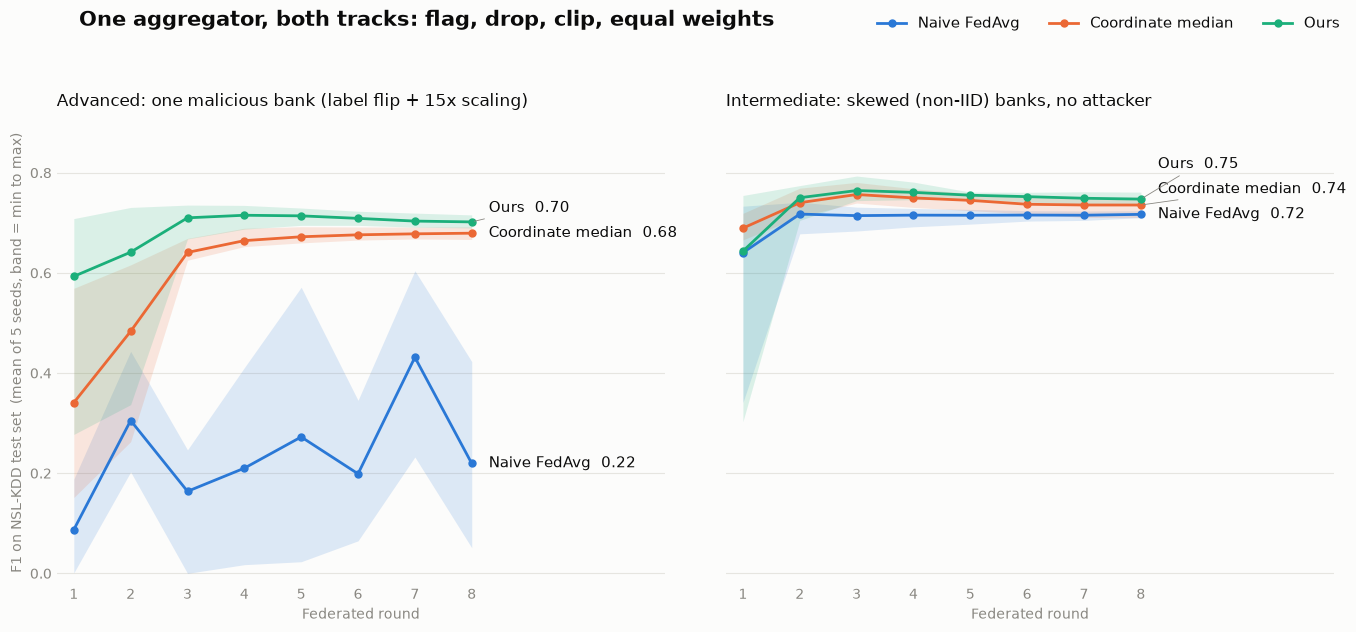

In [14]:
# Cover image: F1 by round, mean of 5 seeds (band = min..max across seeds)
import matplotlib.pyplot as plt
INK, MUTED, SURF = "#0b0b0b", "#898781", "#fcfcfb"
C = {"Naive FedAvg": "#2a78d6", "Coordinate median": "#eb6834", "Ours": "#1baf7a"}
off = ADV["OFFICIAL: bank 1, flip + 15x scale"]
panels = [
    ("Advanced: one malicious bank (label flip + 15x scaling)", off),
    ("Intermediate: skewed (non-IID) banks, no attacker",
     {"Naive FedAvg": INT["Naive FedAvg (BEFORE)"], "Coordinate median": INT["Coordinate median (provided)"], "Ours": INT["Ours (AFTER)"]}),
]
fig, axes = plt.subplots(1, 2, figsize=(14, 6.4), sharey=True, facecolor=SURF)
x = np.arange(1, 9)
for ax, (title, series) in zip(axes, panels):
    ax.set_facecolor(SURF)
    for k, a in series.items():
        ax.fill_between(x, a.min(0), a.max(0), color=C[k], alpha=0.15, lw=0, zorder=2)
        ax.plot(x, a.mean(0), color=C[k], lw=2, marker="o", ms=5, label=k, zorder=3)
    last = -1
    for y, k in sorted((a[:, -1].mean(), k) for k, a in series.items()):   # direct labels, nudged apart
        ly = max(y, last + 0.05); last = ly
        ax.annotate(f"{k}  {y:.2f}", (8, y), xytext=(8.3, ly), color=INK, fontsize=10.5, va="center",
                    arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.6) if abs(ly - y) > 0.01 else None)
    ax.set_title(title, color=INK, fontsize=12.5, loc="left", pad=12)
    ax.set_xlabel("Federated round", color=MUTED); ax.set_xlim(0.7, 11.4); ax.set_xticks(x); ax.set_ylim(-0.02, 0.9)
    ax.grid(axis="y", color="#e6e5e0", lw=0.8); ax.tick_params(colors=MUTED, length=0)
    for s in ax.spines.values(): s.set_visible(False)
axes[0].set_ylabel("F1 on NSL-KDD test set  (mean of 5 seeds, band = min to max)", color=MUTED)
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, loc="upper right", bbox_to_anchor=(0.97, 0.99), ncol=3, fontsize=10.5, labelcolor=INK)
fig.suptitle("One aggregator, both tracks: flag, drop, clip, equal weights", color=INK, fontsize=15, x=0.06, ha="left", weight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93)); fig.savefig("cover.png", dpi=150, facecolor=SURF); plt.show()

### Results summary

In [15]:
# Every headline number in our Writeup, in one place
o = ADV["OFFICIAL: bank 1, flip + 15x scale"]
print("ADVANCED (primary) — official attack, same split/model/rounds")
print(f"  seed 42 (exported model): naive {attacked_history[-1]['f1']:.4f} -> ours {my_defense_history[-1]['f1']:.4f}   recovered +{my_defense_history[-1]['f1'] - attacked_history[-1]['f1']:.4f}   (median {defended_history[-1]['f1']:.4f})")
print(f"  5 seeds:                  naive {ms(o['Naive FedAvg'])} -> ours {ms(o['Ours'])}   recovered +{o['Ours'][:, -1].mean() - o['Naive FedAvg'][:, -1].mean():.4f}   (median {ms(o['Coordinate median'])})")
print("INTERMEDIATE (supporting) — non-IID, no attacker")
print(f"  seed 42:                  naive {noniid_history[-1]['f1']:.4f} -> ours {custom_history[-1]['f1']:.4f}   gain +{custom_history[-1]['f1'] - noniid_history[-1]['f1']:.4f}")
print(f"  5 seeds:                  naive {ms(INT['Naive FedAvg (BEFORE)'])} -> ours {ms(INT['Ours (AFTER)'])}   gain +{INT['Ours (AFTER)'][:, -1].mean() - INT['Naive FedAvg (BEFORE)'][:, -1].mean():.4f}")

ADVANCED (primary) — official attack, same split/model/rounds
  seed 42 (exported model): naive 0.0511 -> ours 0.6938   recovered +0.6427   (median 0.6855)
  5 seeds:                  naive 0.2194 ± 0.1190 -> ours 0.7018 ± 0.0100   recovered +0.4824   (median 0.6793 ± 0.0092)
INTERMEDIATE (supporting) — non-IID, no attacker
  seed 42:                  naive 0.7117 -> ours 0.7467   gain +0.0350
  5 seeds:                  naive 0.7169 ± 0.0057 -> ours 0.7473 ± 0.0088   gain +0.0305


---
## 8. Submission (rubric-graded, no Kaggle leaderboard)

Run this to export your final model. Pick whichever result (intermediate aggregation or
advanced defense) you want judged — set `TRACK` and `FINAL_MODEL` accordingly.

**Input contract:** your exported model's `forward(x)` must accept the standard 41-column
preprocessed feature tensor exactly as produced in Section 1 (`FEATURE_COLS`, same order,
same scaling). If you did feature engineering, build it as extra layers *inside* your model
rather than as a separate preprocessing step.


In [16]:

TEAM_NAME = "ZeroTrustAI"
TRACK = "advanced"  # "intermediate" or "advanced"
FINAL_MODEL = my_defense_model  # <- point this at whichever model you want submitted

final_metrics = evaluate(FINAL_MODEL)

FINAL_MODEL.eval()
scripted = torch.jit.script(FINAL_MODEL)
scripted.save("model_scripted.pt")

submission = {
    "team_name": TEAM_NAME,
    "track": TRACK,
    "self_reported_metrics": final_metrics,
    "model_file": "model_scripted.pt",
    "n_input_features": N_FEATURES,
}
with open("submission.json", "w") as f:
    json.dump(submission, f, indent=2)

print(json.dumps(submission, indent=2))
print("\\nInclude model_scripted.pt and submission.json in your GitHub repo (your Writeup's Project Link).")


{
  "team_name": "ZeroTrustAI",
  "track": "advanced",
  "self_reported_metrics": {
    "precision": 0.9827,
    "recall": 0.5361,
    "f1": 0.6938
  },
  "model_file": "model_scripted.pt",
  "n_input_features": 41
}
\nInclude model_scripted.pt and submission.json in your GitHub repo (your Writeup's Project Link).


/Users/kelvinackah/Desktop/projects/hackaton/secure-ai-competition/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


### What to hand in
1. Your Kaggle Writeup — include the before/after F1 comparison for whichever track(s) you
   attempted, this is your primary evidence for the Automated Detection Score.
2. Your GitHub repo (Project Link) containing `model_scripted.pt`, `submission.json`, and
   this notebook, fully run.
3. Cover image, video (≤3 min), all per the Submission Requirements.
4. Be ready to demo live on Day 7.
